In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, glob
from sklearn.mixture import GaussianMixture
from scipy.ndimage import label as ndlabel
from skimage.measure import label, regionprops

ROOT = r"D:\University\Machine Learning\Dataset\Segmentation"
ORIGINAL_FOLDER = os.path.join(ROOT, "Original Image")
GT_FOLDER = os.path.join(ROOT, "Ground Truth")
PRE_FOLDER = os.path.join(ROOT, "Preprocessed")
BLOCK_SIZE = (100, 100)


In [32]:
# Thế phần này bằng adaptive của trường
def morphological_preprocessing(img_gray, radius=3):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*radius+1, 2*radius+1))
    eroded = cv2.erode(img_gray, kernel)
    opened = cv2.morphologyEx(eroded, cv2.MORPH_OPEN, kernel)
    return cv2.erode(opened, kernel)

for path in glob.glob(os.path.join(ORIGINAL_FOLDER, '*.jpg')):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    norm = morphological_preprocessing(gray)
    median = cv2.medianBlur(norm, 9)
    cv2.imwrite(os.path.join(PRE_FOLDER, os.path.basename(path)), median)
print('Done preprocessing')


Done preprocessing


In [33]:
#Bỏ cái này bài pixel của Phúc 
def detect_seeds(smoothed, k_sigma=1.96):
    mu = np.mean(smoothed)
    sigma = np.std(smoothed)
    return (smoothed < mu - k_sigma * sigma).astype(np.uint8)

def region_growing(smoothed, seeds, n_iter=50, rc_thresh=0.005):
    mask = seeds.copy().astype(np.uint8)
    kernel = np.ones((3,3), np.uint8)
    for i in range(n_iter):
        crack_px = smoothed[mask == 1]
        non_px = smoothed[mask == 0]
        if len(crack_px) == 0 or len(non_px) == 0: break
        z_c = (smoothed - np.mean(crack_px)) / (np.std(crack_px) + 1e-8)
        z_n = (smoothed - np.mean(non_px)) / (np.std(non_px) + 1e-8)
        neighbors = cv2.dilate(mask, kernel).astype(bool)
        cand = neighbors & (mask == 0) & (np.abs(z_n) > 1.96) & (np.abs(z_c) < 1.96)
        prev = np.sum(mask)
        mask[cand] = 1
        if (np.sum(mask) - prev) / (prev + 1e-8) < rc_thresh: break
    return mask


In [34]:

# Patch-based labeling + train GMM
def extract_blocks(img, block_size):
    h, w = img.shape[:2]
    bh, bw = block_size
    rows, cols = h // bh, w // bw
    blocks = []
    for r in range(rows):
        row_b = []
        for c in range(cols):
            row_b.append(img[r*bh:(r+1)*bh, c*bw:(c+1)*bw])
        blocks.append(row_b)
    return np.array(blocks)

def compute_block_mean(blocks):
    rows, cols = blocks.shape[:2]
    M = np.zeros((rows, cols))
    for r in range(rows):
        for c in range(cols):
            M[r, c] = np.mean(blocks[r, c])
    return M

# Fit GMM
all_means = []
for path in glob.glob(os.path.join(PRE_FOLDER, '*.jpg')):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    M = compute_block_mean(extract_blocks(img, BLOCK_SIZE))
    all_means.extend(M.flatten().tolist())
gmm = GaussianMixture(n_components=2, random_state=42).fit(np.array(all_means).reshape(-1,1))
print('GMM means:', gmm.means_.flatten())

def get_patch_mask(img, gmm, block_size, k1=0.4, k2=2.1):
    """Ket hop GMM + Preliminary Labeling (PLB) theo paper Oliveira & Correia."""
    M = compute_block_mean(extract_blocks(img, block_size))
    H, W = M.shape
    # --- GMM labeling ---
    X = M.flatten().reshape(-1, 1)
    preds = gmm.predict(X)
    crack_label = np.argmin(gmm.means_)
    gmm_mask = (preds == crack_label).astype(np.uint8).reshape(M.shape)
    # --- Preliminary Labeling (PLB) theo paper ---
    plb = np.zeros((H, W), dtype=np.uint8)
    # Horizontal: so sanh block (i,j) voi (i,j+1)
    for j in range(W - 1):
        col_vals = M[:, j]
        th_h = k1 * np.std(col_vals) + k2 * np.mean(col_vals)
        for i in range(H):
            pair = np.array([M[i, j], M[i, j+1]])
            if np.std(pair) > th_h and (pair[0] - pair[1]) > 0:
                plb[i, j] = 1
    # Vertical: so sanh block (i,j) voi (i+1,j)
    for i in range(H - 1):
        row_vals = M[i, :]
        th_v = k1 * np.std(row_vals) + k2 * np.mean(row_vals)
        for j in range(W):
            pair = np.array([M[i, j], M[i+1, j]])
            if np.std(pair) > th_v and (pair[0] - pair[1]) > 0:
                plb[i, j] = 1
    # --- Ket hop: union de tang recall ---
    return np.maximum(gmm_mask, plb)


GMM means: [121.69136062  97.92603592]


In [35]:
def relabel_seeds(refined_seeds, patch_mask, block_size, min_width=1, min_length=10):
    '''
    Rang buoc seed bang patch mask.
    Voi moi connected component trong refined_seeds:
      - Dieu kien 1: >= 30% pixel nam trong crack patch
      - Dieu kien 2: width >= min_width VA length >= min_length
    Chi giu lai component thoa man CA HAI dieu kien.
    '''
    bh, bw = block_size
    rows_p, cols_p = patch_mask.shape
    h, w = refined_seeds.shape

    # Upscale patch mask sang pixel-level
    patch_pixel = np.zeros((h, w), dtype=np.uint8)
    for r in range(rows_p):
        for c in range(cols_p):
            if patch_mask[r, c] == 1:
                patch_pixel[r*bh:(r+1)*bh, c*bw:(c+1)*bw] = 1

    labels_img = label(refined_seeds)
    final = np.zeros_like(refined_seeds, dtype=np.uint8)

    for region in regionprops(labels_img):
        comp = (labels_img == region.label)
        total = np.sum(comp)
        in_patch = np.sum(comp & (patch_pixel == 1))

        # Dieu kien 1: Nam trong crack patch (5%)
        if in_patch / (total + 1e-8) < 0.05:
            continue

        # Dieu kien 2: Thoa man threshold width & length
        minr, minc, maxr, maxc = region.bbox
        comp_w = min(maxr - minr, maxc - minc)
        comp_l = region.major_axis_length
        if comp_w < min_width or comp_l < min_length:
            continue

        final[comp] = 1

    return final


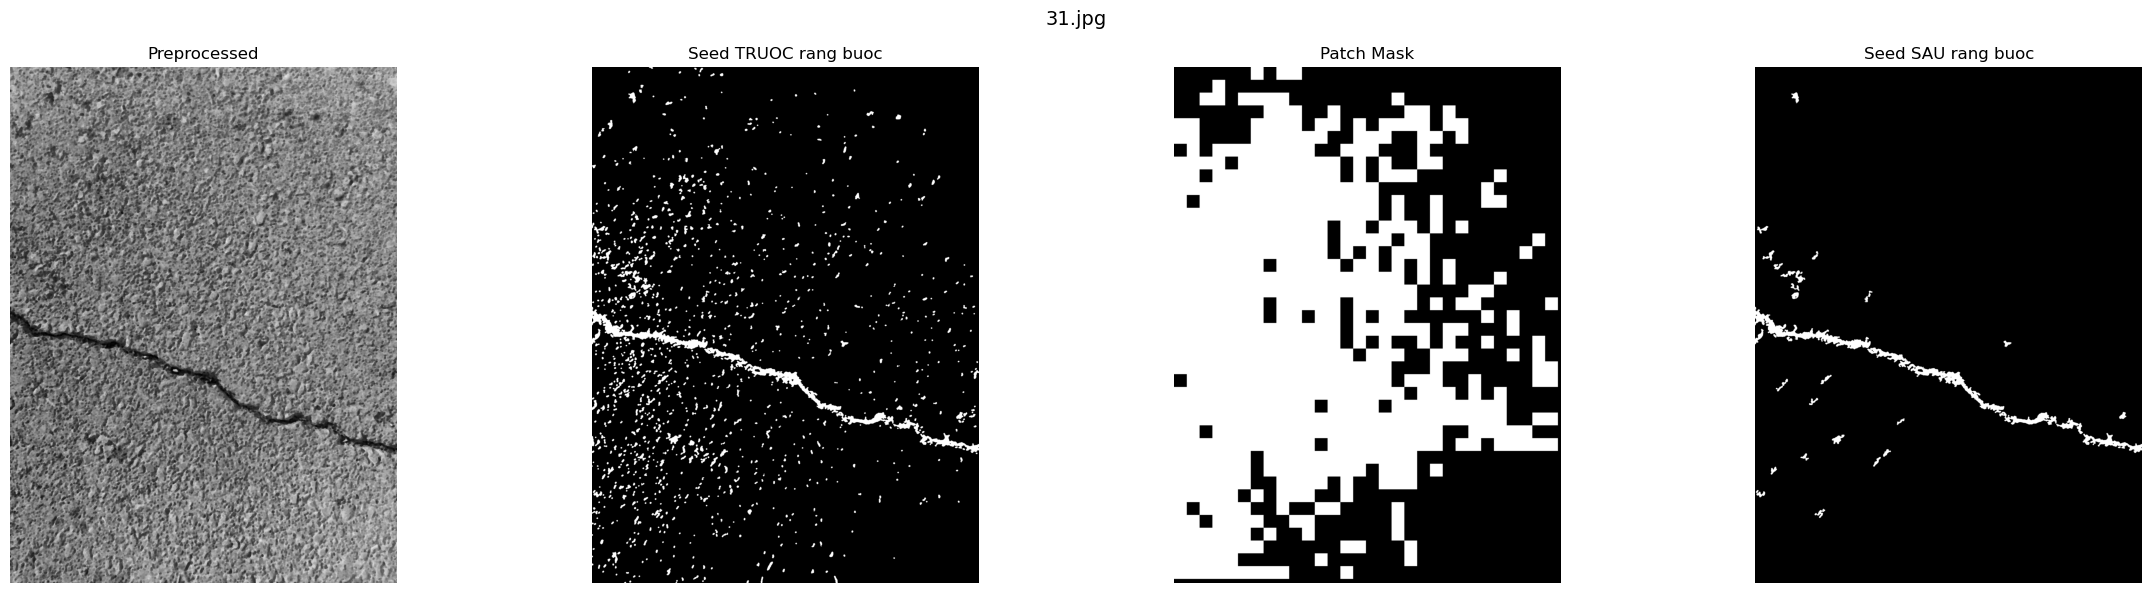

In [36]:
# Chon anh
idx = 55
pre_path = sorted(glob.glob(os.path.join(PRE_FOLDER, '*.jpg')))[idx]
name = os.path.basename(pre_path)
smoothed = cv2.imread(pre_path,cv2.IMREAD_GRAYSCALE)

# Step 1: Seed detection + region growing
seeds_raw = detect_seeds(smoothed, k_sigma=1.96)
refined_seeds = region_growing(smoothed, seeds_raw)

# Step 2: Patch mask (PLB + GMM)
patch_mask = get_patch_mask(smoothed, gmm, BLOCK_SIZE)

# Step 3: Relabeling (relaxed constraints)
final = relabel_seeds(refined_seeds, patch_mask, BLOCK_SIZE, min_width=50, min_length=50)

# Upscale patch mask
bh, bw = BLOCK_SIZE
h, w = smoothed.shape
patch_vis = np.zeros((h, w), dtype=np.uint8)
for r in range(patch_mask.shape[0]):
    for c in range(patch_mask.shape[1]):
        if patch_mask[r, c] == 1:
            patch_vis[r*bh:(r+1)*bh, c*bw:(c+1)*bw] = 255

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(smoothed, cmap='gray'); axes[0].set_title('Preprocessed'); axes[0].axis('off')
axes[1].imshow(refined_seeds * 255, cmap='gray'); axes[1].set_title('Seed TRUOC rang buoc'); axes[1].axis('off')
axes[2].imshow(patch_vis, cmap='gray'); axes[2].set_title('Patch Mask'); axes[2].axis('off')
axes[3].imshow(final * 255, cmap='gray'); axes[3].set_title('Seed SAU rang buoc'); axes[3].axis('off')
plt.suptitle(name, fontsize=14)
plt.tight_layout(); plt.show()
